# 전이학습을 이용한 꽃 이미지 분류

Pre-trained MobileNetV2 모델을 사용하여 꽃 이미지를 분류하는 모델을 만듭니다.

## 1. 필요한 라이브러리 import

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 2. 데이터 로드 및 전처리

TensorFlow에서 제공하는 꽃 데이터셋을 다운로드하고 전처리합니다.

In [3]:
# 꽃 이미지 데이터셋 다운로드 URL
# - TensorFlow 공식 예제에서 제공하는 flower_photos 데이터셋
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# TensorFlow 유틸리티 함수를 이용해 데이터셋 다운로드 및 압축 해제
# - fname='flower_photos' : ~/.keras/datasets/flower_photos/ 폴더에 캐시
# - origin : 다운로드할 원본 URL
# - untar=True : .tgz 파일을 자동으로 압축 해제
# 반환값(base_dir)은 압축이 해제된 "최상위 캐시 디렉토리" 경로
base_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    untar=True
)

# 실제 이미지들이 들어 있는 디렉토리 경로 설정
# - 압축 파일 내부에 flower_photos/ 폴더가 한 번 더 포함되어 있음
# - 따라서 base_dir 아래의 flower_photos 폴더를 실제 데이터 경로로 사용
data_dir = os.path.join(base_dir, "flower_photos")

# 최종 데이터 경로 출력 (확인용)
print(f"데이터 경로: {data_dir}")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
데이터 경로: /root/.keras/datasets/flower_photos/flower_photos


In [4]:
# 모델에 입력될 이미지 크기 (Height, Width)
# - 사전학습 CNN(ResNet, VGG 등)은 보통 224x224 사용
IMG_SIZE = (224, 224)

# 한 번에 모델에 입력될 이미지 개수 (배치 크기)
BATCH_SIZE = 32

# ImageDataGenerator를 이용한 데이터 전처리 및 증강
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # 사전학습 모델에 맞는 전처리
    validation_split=0.2,                      # 전체 데이터 중 20%를 검증용으로 분리

    # -------- 데이터 증강(Data Augmentation) 옵션 --------
    rotation_range=20,        # 이미지 회전 범위 (±20도)
    width_shift_range=0.2,    # 가로 방향 이동 비율 (20%)
    height_shift_range=0.2,   # 세로 방향 이동 비율 (20%)
    horizontal_flip=True,     # 좌우 반전
    zoom_range=0.2            # 확대/축소 비율 (±20%)
)

# 훈련 데이터 로더 생성
train_generator = train_datagen.flow_from_directory(
    data_dir,                 # 이미지들이 들어 있는 최상위 디렉토리
    target_size=IMG_SIZE,     # 모든 이미지를 IMG_SIZE로 리사이즈
    batch_size=BATCH_SIZE,    # 배치 크기
    class_mode='categorical', # 다중 분류 → one-hot 라벨 생성
    subset='training',        # validation_split 중 훈련용 데이터 선택
    shuffle=True              # 학습 시 데이터 섞기 (필수)
)

# 검증 데이터 로더 생성
# 동일한 ImageDataGenerator를 사용하되 subset만 'validation'으로 지정
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',      # validation 데이터 선택
    shuffle=False             # 검증/평가 시에는 보통 섞지 않음
)

# 분류 클래스 개수 출력
print(f"\n클래스 수: {train_generator.num_classes}")

# 클래스 이름과 인덱스 매핑 확인
print(f"클래스 이름: {list(train_generator.class_indices.keys())}")

# 훈련 데이터 샘플 수
print(f"훈련 샘플 수: {train_generator.samples}")

# 검증 데이터 샘플 수
print(f"검증 샘플 수: {validation_generator.samples}")

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

클래스 수: 5
클래스 이름: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
훈련 샘플 수: 2939
검증 샘플 수: 731


## 3. 데이터 시각화

로드된 이미지 데이터를 확인합니다.

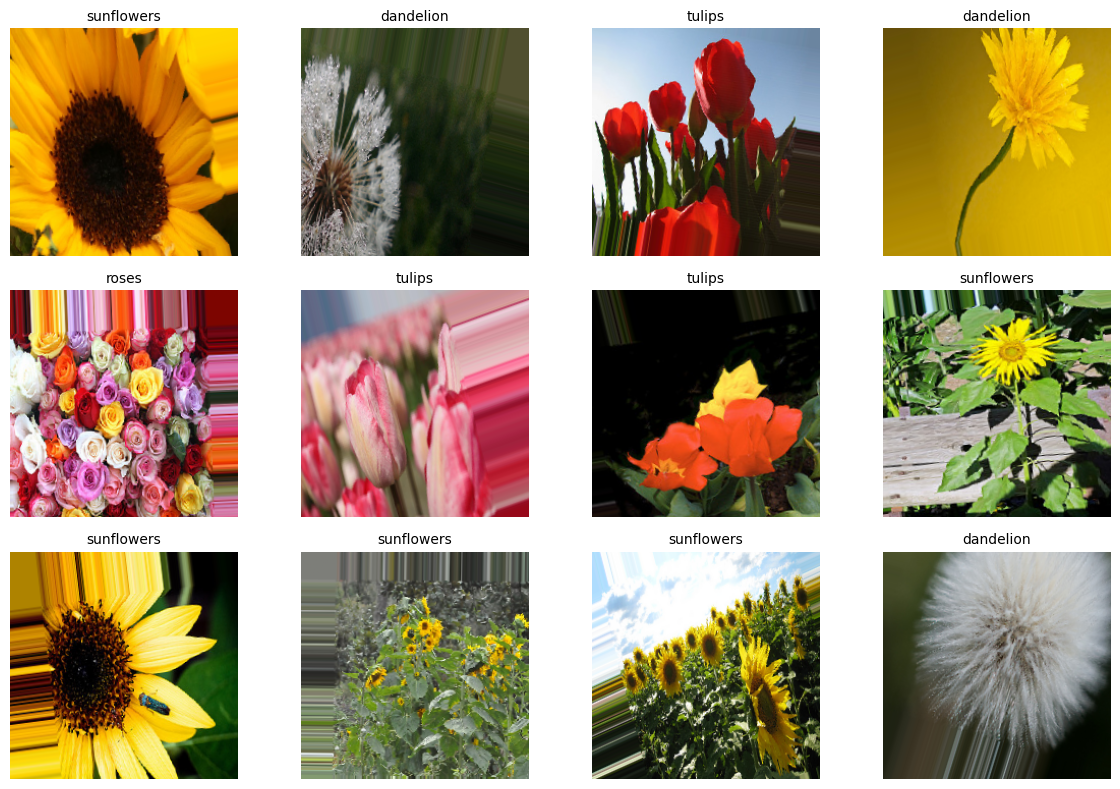

In [5]:
# 배치 하나 가져오기
sample_images, sample_labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

# 이미지 시각화
plt.figure(figsize=(12, 8))
for i in range(min(12, len(sample_images))):
    plt.subplot(3, 4, i+1)
    # preprocess_input이 적용된 이미지는 역정규화 필요
    img = sample_images[i]
    img = (img + 1) / 2  # [-1, 1] 범위를 [0, 1]로 변환
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    label_idx = np.argmax(sample_labels[i])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Pre-trained 모델 로드

ImageNet으로 사전 학습된 MobileNetV2를 feature extractor로 사용합니다.

In [6]:
# Base model 생성 (top layer 제거)
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,  # 분류 레이어 제거
    weights='imagenet'  # ImageNet 사전 학습 가중치 사용
)

# Base model의 가중치는 학습하지 않음 (freeze)
base_model.trainable = False

print("Base model 요약:")
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model 요약:


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. 모델 구성

Base model 위에 새로운 분류 레이어를 추가합니다.

* GlobalAveragePooling2D() - 공간 정보를 “평균으로 요약”해서 채널별 대표값만 남기는 층.
```
(None, 7, 7, 512) --> (None, 512)
```

In [7]:
# 전체 모델 구성
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Feature map을 벡터로 변환
    layers.Dropout(0.2),  # 과적합 방지
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_generator.num_classes, activation='softmax', name='predictions')
])

# 모델 컴파일
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("전체 모델 구조:")
model.summary()

전체 모델 구조:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. 모델 학습

Feature extraction 단계에서 모델을 학습시킵니다.

In [8]:
EPOCHS = 10

callbacks = [
    # - 검증 성능이 더 이상 좋아지지 않으면 학습을 조기에 종료
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',      # 감시할 지표 (검증 정확도)
        patience=3,                  # 개선이 없을 때 기다릴 epoch 수
        restore_best_weights=True    # 가장 성능이 좋았던 가중치로 복원
    ),

    # ReduceLROnPlateau
    # - 검증 손실이 정체되면 학습률(learning rate)을 감소
    # - 최적점 근처에서 더 세밀한 학습 가능
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',   # 감시할 지표 (검증 손실)
        factor=0.5,           # 학습률 감소 비율 (기존의 50%)
        patience=2,           # 개선이 없을 때 기다릴 epoch 수
        min_lr=1e-7           # 학습률의 최소값 (너무 작아지는 것 방지)
    )
]

# 모델 학습 실행
history = model.fit(
    train_generator,              # 훈련 데이터 제너레이터
    epochs=EPOCHS,                # 최대 학습 epoch 수
    validation_data=validation_generator,  # 검증 데이터
    callbacks=callbacks,          # 콜백 목록
    verbose=1                     # 학습 로그 출력 수준 (1 = 진행 바 표시)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 87s 741ms/step - accuracy: 0.6083 - loss: 1.0264 - val_accuracy: 0.8235 - val_loss: 0.4774 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 544ms/step - accuracy: 0.8350 - loss: 0.4556 - val_accuracy: 0.8605 - val_loss: 0.3953 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 543ms/step - accuracy: 0.8616 - loss: 0.3552 - val_accuracy: 0.8714 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 536ms/step - accuracy: 0.8691 - loss: 0.3416 - val_accuracy: 0.8700 - val_loss: 0.3648 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 527ms/step - accuracy: 0.8900 - loss: 0.2992 - val_accuracy: 0.8427 - val_loss: 0.4283 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 527ms/step - accuracy: 0.8974 - loss: 0.2684 - val_accuracy: 0.8687 - val_loss: 0.3664 - learning_rate: 5.0000e-04


## 7. 학습 과정 시각화

학습 과정에서의 정확도와 손실을 그래프로 확인합니다.

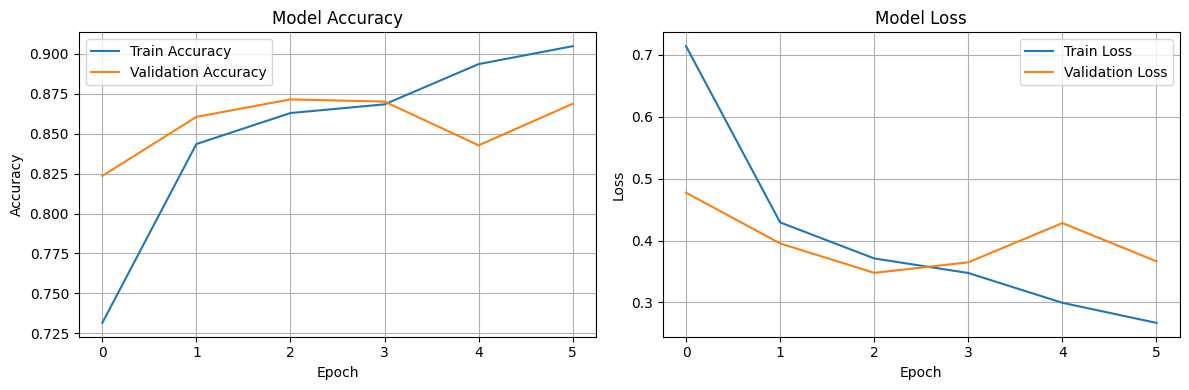

In [9]:
# 학습 히스토리 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 정확도
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# 손실
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. 모델 평가

검증 데이터로 모델의 성능을 평가합니다.

In [10]:
# 모델 평가
test_loss, test_accuracy = model.evaluate(validation_generator, verbose=0)
print(f"검증 손실: {test_loss:.4f}")
print(f"검증 정확도: {test_accuracy:.4f}")

검증 손실: 0.3634
검증 정확도: 0.8769


## 9. 예측 결과 시각화

검증 데이터에 대한 예측 결과를 시각화합니다.

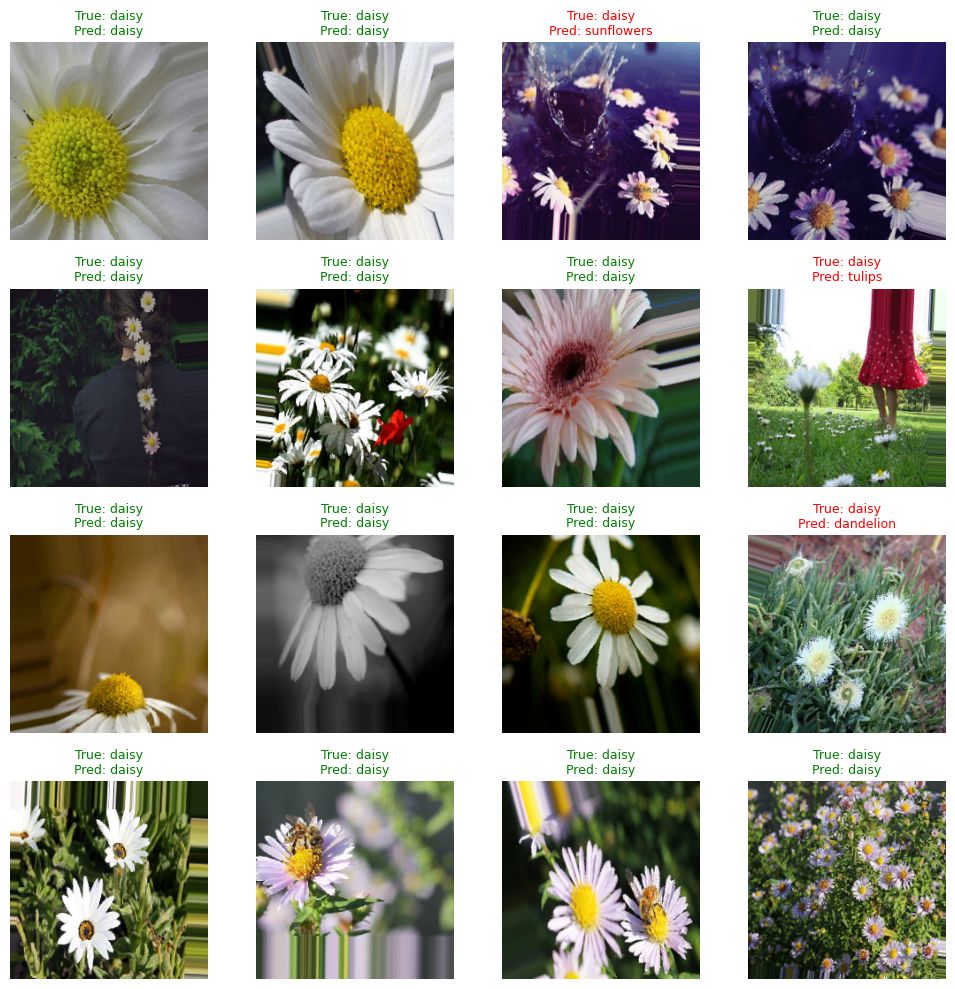

In [11]:
# 검증 데이터에서 한 배치(batch) 가져오기
# val_images: (batch_size, height, width, channels)
# val_labels: (batch_size, num_classes)  ← one-hot 라벨
val_images, val_labels = next(validation_generator)

# 배치 이미지에 대해 모델 예측 수행
predictions = model.predict(val_images, verbose=0)

# 예측 확률 중 가장 큰 값을 가지는 인덱스를 선택
predicted_classes = np.argmax(predictions, axis=1)

# one-hot 형태의 실제 라벨을 클래스 번호로 변환
true_classes = np.argmax(val_labels, axis=1)

# 예측 결과 시각화
plt.figure(figsize=(10, 10))

# 최대 16개 이미지를 4x4 격자로 시각화
for i in range(min(16, len(val_images))):
    plt.subplot(4, 4, i + 1)

    # preprocess_input에 의해 [-1, 1] 범위로 정규화된 이미지를
    # 다시 사람이 보기 좋은 [0, 1] 범위로 복원
    img = val_images[i]
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)

    # 이미지 출력
    plt.imshow(img)

    # 실제 클래스 이름
    true_label = class_names[true_classes[i]]
    # 예측 클래스 이름
    pred_label = class_names[predicted_classes[i]]

    # 예측이 맞으면 초록색, 틀리면 빨간색으로 표시
    color = 'green' if true_classes[i] == predicted_classes[i] else 'red'

    # 제목에 실제 라벨 / 예측 라벨 / 확률 표시
    plt.title(
        f'True: {true_label}\nPred: {pred_label}',
        color=color,
        fontsize=9
    )

    # 축 눈금 제거
    plt.axis('off')

plt.tight_layout()
plt.show()

## 10. 혼동 행렬 (Confusion Matrix)

각 클래스별 분류 성능을 확인합니다.

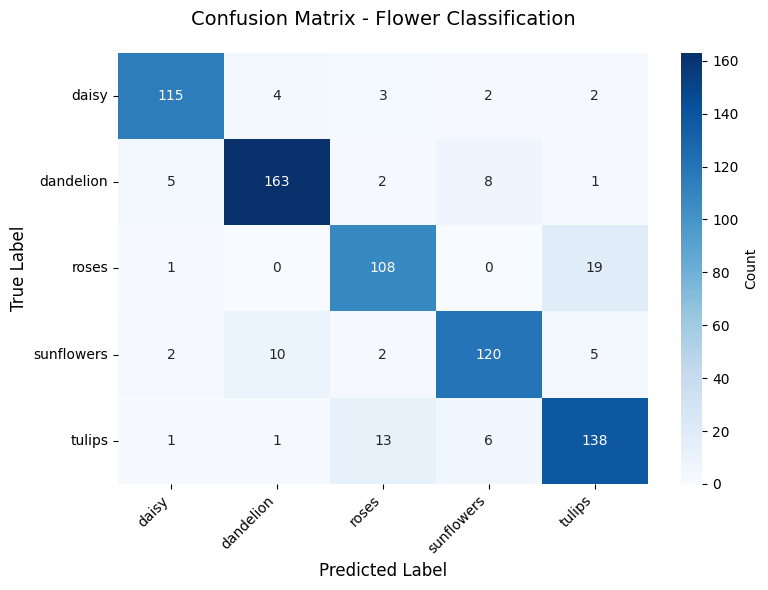

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 전체 검증 데이터에 대한 예측 수행

# validation_generator를 명시적으로 참조
val_generator = validation_generator

# 제너레이터의 내부 인덱스를 처음으로 되돌림
val_generator.reset()

# 전체 예측 결과와 실제 라벨을 저장할 리스트
all_preds = []
all_labels = []

# validation_generator의 전체 배치 수만큼 반복
for i in range(len(val_generator)):

    # 한 배치(batch)의 이미지와 라벨 로드
    images, labels = next(val_generator)

    # 현재 배치 이미지에 대해 모델 예측 수행
    preds = model.predict(images, verbose=0)

    # 예측 확률 중 가장 큰 값을 가지는 인덱스 선택 (예측 클래스)
    all_preds.extend(np.argmax(preds, axis=1))

    # one-hot 형태의 실제 라벨을 클래스 인덱스로 변환
    all_labels.extend(np.argmax(labels, axis=1))

    # 안전 장치: 마지막 배치를 넘어가지 않도록 종료
    if i >= len(val_generator) - 1:
        break

# 혼동 행렬 시각화
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,  annot=True, fmt='d',              # 정수형 포맷
    cmap='Blues',         # 색상 맵
    xticklabels=class_names,  # 예측 클래스 이름
    yticklabels=class_names,  # 실제 클래스 이름
    cbar_kws={'label': 'Count'}  # 컬러바 레이블
)

# 축 라벨 및 제목 설정
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Flower Classification', fontsize=14, pad=20)

# x축 클래스 이름 기울여서 표시
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()